
# 08 — Final Analysis, Error Review, Visuals


Notebook purpose: consolidate the final modeling results and centers the selected model, **Sentence-transformer embeddings (all-MiniLM-L6-v2) with logistic regression using title plus description.**

Rebuild a clean final model-comparison table, create visuals, show the selected model's held-out confusion matrix, show held-out per-class F1 with class support, summarize grouped cross-validation robustnes, compare fixed held-out performance with grouped-CV performance, organize sentence-embedding errors into meaningful categories, export tables and figures

## Evaluation hierarchy

- Primary result: held-out parks
- Secondary result: mixed parks
- Primary metric: Macro F1
- Robustness check: grouped cross-validation by park


## 1. Imports and display settings

In [ ]:

from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    precision_recall_fscore_support,
)

warnings.filterwarnings("ignore")

PRIMARY_LABELS = [
    "trail_or_area_access",
    "road_parking_transportation",
    "weather_fire_environmental_hazard",
    "wildlife_hazard_or_restriction",
    "facility_water_campground_service",
    "construction_maintenance_general",
]

DISPLAY_LABELS = {
    "trail_or_area_access": "Trail / area access",
    "road_parking_transportation": "Road / parking / transportation",
    "weather_fire_environmental_hazard": "Weather / fire / environmental",
    "wildlife_hazard_or_restriction": "Wildlife hazard / restriction",
    "facility_water_campground_service": "Facility / campground / service",
    "construction_maintenance_general": "General / minor issue",
}

MODEL_LABELS = {
    "Majority baseline": "Majority",
    "Keyword/rule baseline": "Rules",
    "TF-IDF + logistic regression": "TF-IDF",
    "Sentence embeddings + logistic regression": "Sentence embeddings",
    "Fine-tuned DistilBERT": "DistilBERT",
}

plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10


## 2. Locate project files

In [ ]:

SEARCH_DIRS = [
    Path("/content"),
    Path("/mnt/data"),
    Path("."),
]

def find_latest_file(patterns, required=True):
    matches = []
    for directory in SEARCH_DIRS:
        for pattern in patterns:
            matches.extend(directory.glob(pattern))

    matches = sorted(
        {path.resolve() for path in matches},
        key=lambda path: path.stat().st_mtime,
    )

    if matches:
        return matches[-1]

    if required:
        raise FileNotFoundError(
            "Could not find any file matching: "
            + ", ".join(patterns)
        )
    return None


MODELING_PATH = find_latest_file([
    "nps_gold_modeling_dataset_with_splits*.csv",
])

ALL_MODELS_PATH = find_latest_file([
    "all_models_metrics*.csv",
])

GENERALIZATION_PATH = find_latest_file([
    "all_models_generalization_gap*.csv",
])

EMBEDDING_PREDICTIONS_PATH = find_latest_file([
    "embedding_predictions*.csv",
])

EMBEDDING_PER_CLASS_PATH = find_latest_file([
    "embedding_per_class_metrics*.csv",
])

GROUPED_CV_FOLDS_PATH = find_latest_file([
    "embedding_grouped_cv_folds*.csv",
])

GROUPED_CV_SUMMARY_PATH = find_latest_file([
    "embedding_grouped_cv_summary*.csv",
])

EMBEDDING_ERRORS_PATH = find_latest_file([
    "embedding_test_errors*.csv",
], required=False)

DISTILBERT_PREDICTIONS_PATH = find_latest_file([
    "distilbert_predictions*.csv",
], required=False)

print("Modeling data:", MODELING_PATH)
print("All-model metrics:", ALL_MODELS_PATH)
print("Generalization gap:", GENERALIZATION_PATH)
print("Embedding predictions:", EMBEDDING_PREDICTIONS_PATH)
print("Embedding per-class metrics:", EMBEDDING_PER_CLASS_PATH)
print("Grouped CV folds:", GROUPED_CV_FOLDS_PATH)
print("Grouped CV summary:", GROUPED_CV_SUMMARY_PATH)
print("Embedding test errors:", EMBEDDING_ERRORS_PATH)
print("DistilBERT predictions:", DISTILBERT_PREDICTIONS_PATH)


Modeling data: /content/nps_gold_modeling_dataset_with_splits.csv
All-model metrics: /content/all_models_metrics.csv
Generalization gap: /content/all_models_generalization_gap.csv
Embedding predictions: /content/embedding_predictions.csv
Embedding per-class metrics: /content/embedding_per_class_metrics.csv
Grouped CV folds: /content/embedding_grouped_cv_folds.csv
Grouped CV summary: /content/embedding_grouped_cv_summary.csv
Embedding test errors: /content/embedding_test_errors.csv
DistilBERT predictions: /content/distilbert_predictions.csv


## 3. Load and standardize the data

In [ ]:

modeling_df = pd.read_csv(MODELING_PATH)
all_models_df = pd.read_csv(ALL_MODELS_PATH)
generalization_df = pd.read_csv(GENERALIZATION_PATH)
embedding_predictions_df = pd.read_csv(EMBEDDING_PREDICTIONS_PATH)
embedding_per_class_df = pd.read_csv(EMBEDDING_PER_CLASS_PATH)
grouped_cv_folds_df = pd.read_csv(GROUPED_CV_FOLDS_PATH)
grouped_cv_summary_df = pd.read_csv(GROUPED_CV_SUMMARY_PATH)

embedding_errors_df = (
    pd.read_csv(EMBEDDING_ERRORS_PATH)
    if EMBEDDING_ERRORS_PATH is not None
    else None
)

distilbert_predictions_df = (
    pd.read_csv(DISTILBERT_PREDICTIONS_PATH)
    if DISTILBERT_PREDICTIONS_PATH is not None
    else None
)

# Harmonize model display names.
all_models_df["model_short"] = (
    all_models_df["model"]
    .map(MODEL_LABELS)
    .fillna(all_models_df["model"])
)

# Keep only test rows for final model comparison.
test_models_df = (
    all_models_df.loc[
        all_models_df["partition"].eq("test")
    ]
    .copy()
)

selected_model_name = (
    "Sentence embeddings + logistic regression"
)

selected_test_df = test_models_df.loc[
    test_models_df["model"].eq(selected_model_name)
].copy()

print("Final test rows:", len(test_models_df))
print("Selected model test rows:", len(selected_test_df))

display(
    test_models_df[
        [
            "evaluation_setting",
            "model_short",
            "accuracy",
            "macro_f1",
            "weighted_f1",
        ]
    ]
    .sort_values(
        ["evaluation_setting", "macro_f1"],
        ascending=[True, False],
    )
    .reset_index(drop=True)
)


Final test rows: 10
Selected model test rows: 2


,evaluation_setting,model_short,accuracy,macro_f1,weighted_f1
0,Held-out parks,Sentence embeddings,0.800000,0.763879,0.800868
1,Held-out parks,DistilBERT,0.755556,0.638624,0.740670
2,Held-out parks,Rules,0.622222,0.583125,0.634424
3,Held-out parks,TF-IDF,0.666667,0.450246,0.635380
4,Held-out parks,Majority,0.311111,0.079096,0.147646
5,Mixed parks,Sentence embeddings,0.777778,0.659578,0.757633
6,Mixed parks,DistilBERT,0.755556,0.631746,0.732275
7,Mixed parks,TF-IDF,0.755556,0.623739,0.744132
8,Mixed parks,Rules,0.622222,0.603385,0.660143
9,Mixed parks,Majority,0.288889,0.074713,0.129502



## 4. Final model-comparison table

The held-out-park setting is the primary result. The mixed-park setting is retained as a secondary comparison.


In [ ]:

final_comparison_table = (
    test_models_df
    .pivot_table(
        index="model_short",
        columns="evaluation_setting",
        values=["accuracy", "macro_f1", "weighted_f1"],
        aggfunc="first",
    )
)

# Flatten the multi-index columns.
final_comparison_table.columns = [
    f"{metric}_{setting}"
    for metric, setting in final_comparison_table.columns
]

final_comparison_table = (
    final_comparison_table
    .reset_index()
)

model_order = [
    "Majority",
    "Rules",
    "TF-IDF",
    "Sentence embeddings",
    "DistilBERT",
]

final_comparison_table["model_order"] = (
    final_comparison_table["model_short"]
    .map({
        model: index
        for index, model in enumerate(model_order)
    })
)

final_comparison_table = (
    final_comparison_table
    .sort_values("model_order")
    .drop(columns="model_order")
    .reset_index(drop=True)
)

display(final_comparison_table.round(3))


,model_short,accuracy_Held-out parks,accuracy_Mixed parks,macro_f1_Held-out parks,macro_f1_Mixed parks,weighted_f1_Held-out parks,weighted_f1_Mixed parks
0,Majority,0.311,0.289,0.079,0.075,0.148,0.130
1,Rules,0.622,0.622,0.583,0.603,0.634,0.660
2,TF-IDF,0.667,0.756,0.450,0.624,0.635,0.744
3,Sentence embeddings,0.800,0.778,0.764,0.660,0.801,0.758
4,DistilBERT,0.756,0.756,0.639,0.632,0.741,0.732


# Figures

## Figure 1. Final model comparison

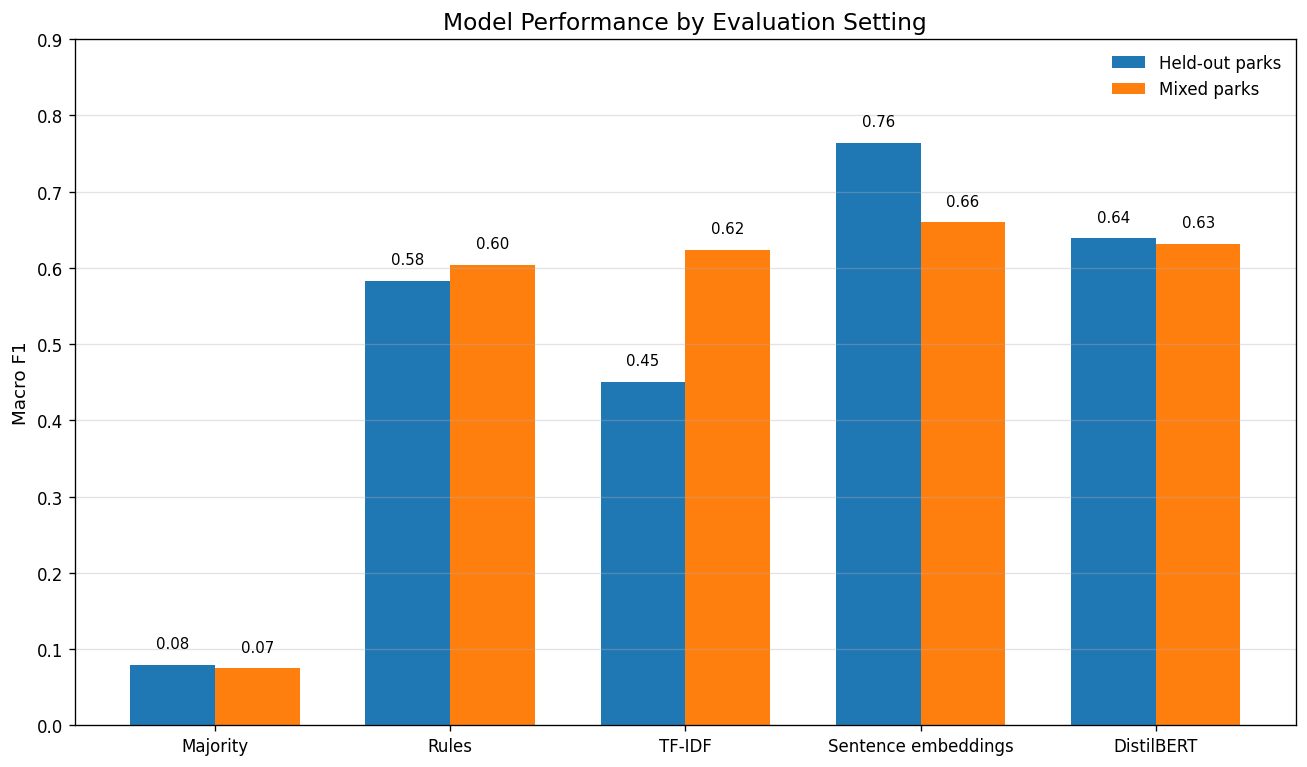

In [ ]:

plot_df = (
    test_models_df
    .pivot_table(
        index="model_short",
        columns="evaluation_setting",
        values="macro_f1",
        aggfunc="first",
    )
    .reindex(model_order)
)

x = np.arange(len(plot_df))
width = 0.36

fig, ax = plt.subplots(figsize=(11, 6.5))

heldout_values = plot_df["Held-out parks"]
mixed_values = plot_df["Mixed parks"]

ax.bar(
    x - width / 2,
    heldout_values,
    width,
    label="Held-out parks",
)

ax.bar(
    x + width / 2,
    mixed_values,
    width,
    label="Mixed parks",
)

ax.set_ylabel("Macro F1")
ax.set_title("Model Performance by Evaluation Setting")
ax.set_xticks(x)
ax.set_xticklabels(plot_df.index)
ax.set_ylim(0, 0.9)
ax.legend(frameon=False)
ax.grid(axis="y", linewidth=0.8, alpha=0.35)

for index, value in enumerate(heldout_values):
    ax.text(
        index - width / 2,
        value + 0.018,
        f"{value:.2f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

for index, value in enumerate(mixed_values):
    ax.text(
        index + width / 2,
        value + 0.018,
        f"{value:.2f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

plt.tight_layout()
plt.show()



### Interpretation

Main results figure. It shows that sentence embeddings achieved the strongest held-out-park Macro F1, while DistilBERT performed more similarly across the two settings but did not exceed the frozen embedding model.


## Figure 2. Generalization gap by model

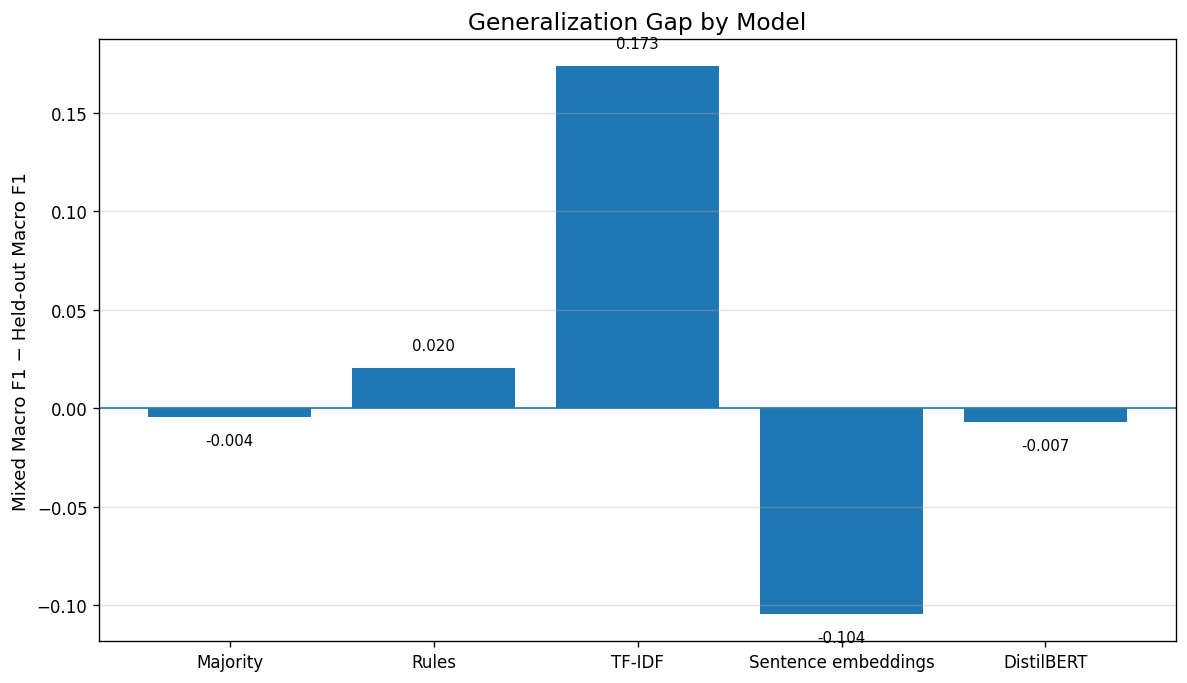

In [ ]:

gap_df = generalization_df.copy()

if "model_short" not in gap_df.columns:
    gap_df["model_short"] = (
        gap_df["model"]
        .map(MODEL_LABELS)
        .fillna(gap_df["model"])
    )

gap_col = (
    "Generalization gap"
    if "Generalization gap" in gap_df.columns
    else "generalization_gap"
)

gap_df = (
    gap_df
    .set_index("model_short")
    .reindex(model_order)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 5.8))

ax.bar(
    gap_df["model_short"],
    gap_df[gap_col],
)

ax.axhline(0, linewidth=1)
ax.set_ylabel("Mixed Macro F1 − Held-out Macro F1")
ax.set_title("Generalization Gap by Model")
ax.grid(axis="y", linewidth=0.8, alpha=0.35)

for index, value in enumerate(gap_df[gap_col]):
    vertical_alignment = "bottom" if value >= 0 else "top"
    offset = 0.008 if value >= 0 else -0.008
    ax.text(
        index,
        value + offset,
        f"{value:.3f}",
        ha="center",
        va=vertical_alignment,
        fontsize=9,
    )

plt.tight_layout()
plt.show()



### Interpretation

A positive value means performance was higher in the mixed-park setting. A negative value means the fixed held-out test happened to produce a higher score. Negative values should not be interpreted as proof that unseen parks are easier because the test sets are small and may differ in difficulty.


## Figure 3. Gold-standard class distribution

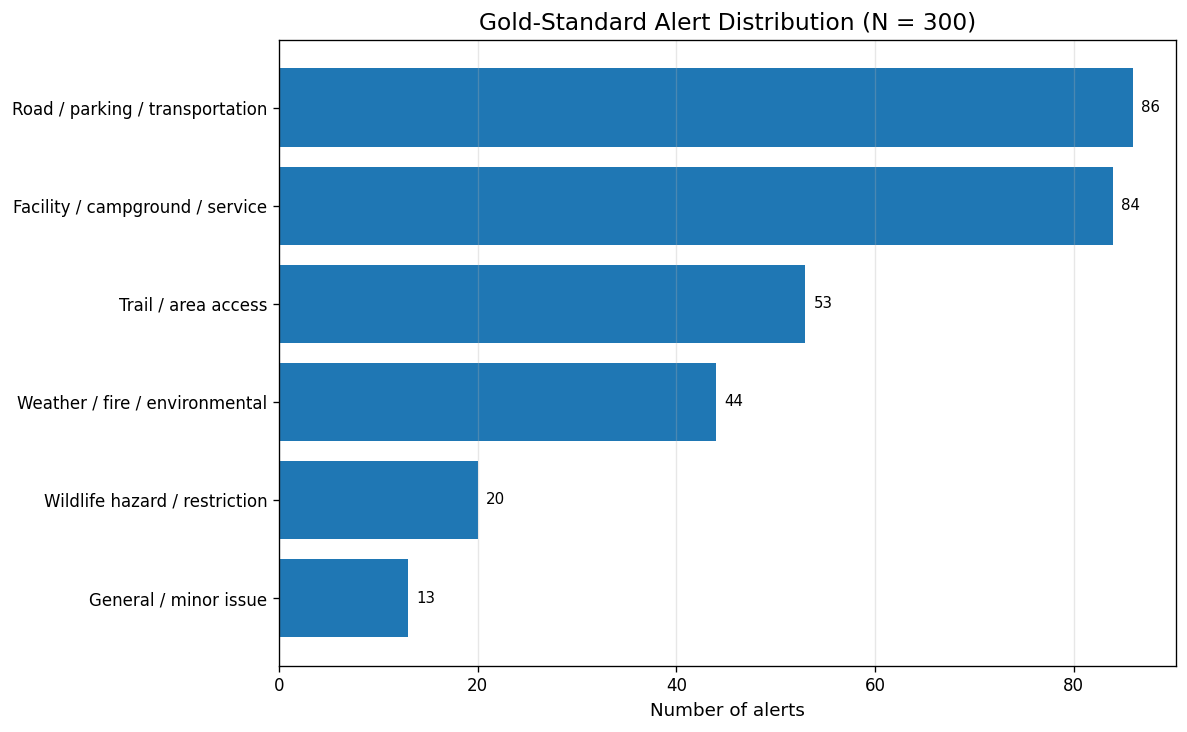

In [ ]:

class_counts = (
    modeling_df["primary_label"]
    .value_counts()
    .reindex(PRIMARY_LABELS, fill_value=0)
)

class_plot_df = pd.DataFrame({
    "label": class_counts.index,
    "display_label": [
        DISPLAY_LABELS[label]
        for label in class_counts.index
    ],
    "count": class_counts.values,
}).sort_values("count", ascending=True)

fig, ax = plt.subplots(figsize=(10, 6.2))

ax.barh(
    class_plot_df["display_label"],
    class_plot_df["count"],
)

ax.set_xlabel("Number of alerts")
ax.set_title("Gold-Standard Alert Distribution (N = 300)")
ax.grid(axis="x", linewidth=0.8, alpha=0.3)

for index, value in enumerate(class_plot_df["count"]):
    ax.text(
        value + 0.8,
        index,
        str(value),
        va="center",
        fontsize=9,
    )

plt.tight_layout()
plt.show()


## Figure 4. Selected-model held-out confusion matrix

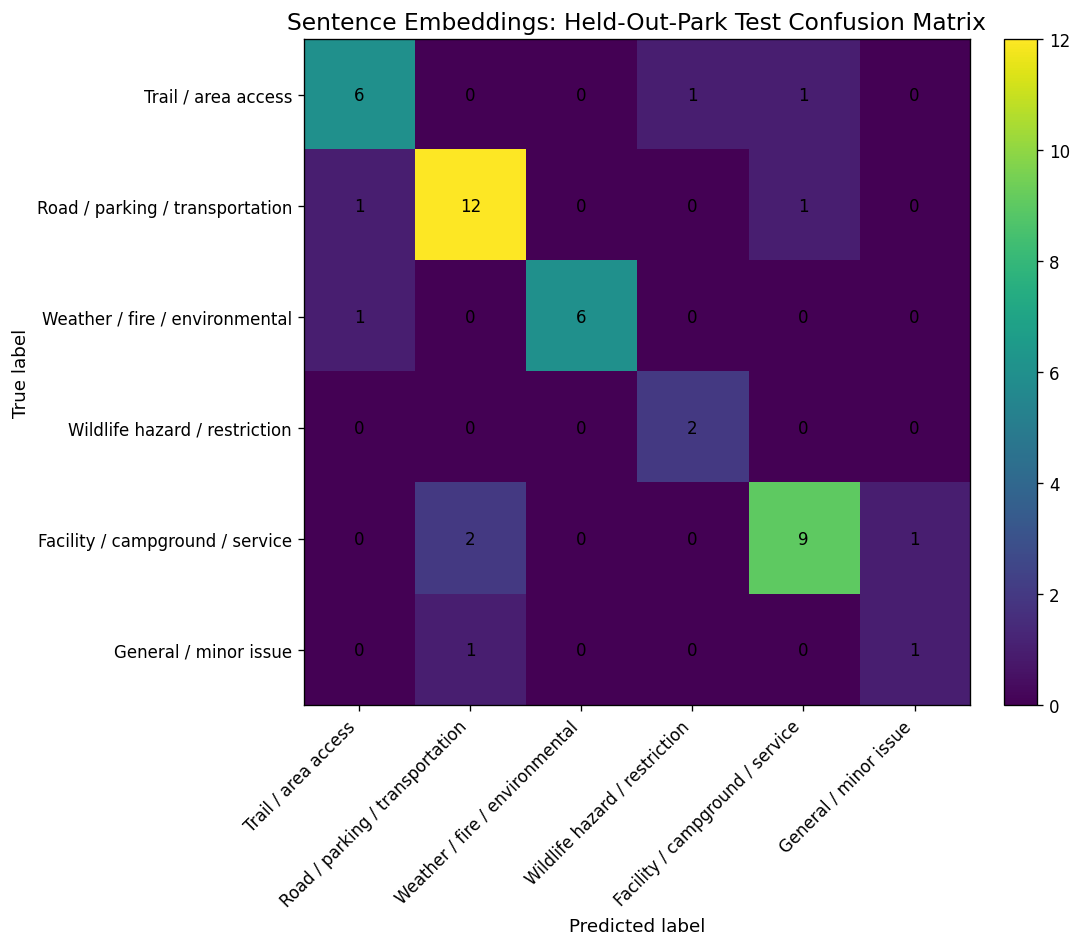

In [ ]:

selected_heldout_predictions = (
    embedding_predictions_df.loc[
        embedding_predictions_df[
            "evaluation_setting"
        ].eq("Held-out parks")
        & embedding_predictions_df[
            "partition"
        ].eq("test")
    ]
    .copy()
)

if selected_heldout_predictions.empty:
    raise ValueError(
        "No held-out test rows were found in embedding_predictions."
    )

matrix = confusion_matrix(
    selected_heldout_predictions["primary_label"],
    selected_heldout_predictions["predicted_label"],
    labels=PRIMARY_LABELS,
)

display_names = [
    DISPLAY_LABELS[label]
    for label in PRIMARY_LABELS
]

fig, ax = plt.subplots(figsize=(9.5, 8))

image = ax.imshow(matrix)

ax.set_xticks(np.arange(len(display_names)))
ax.set_yticks(np.arange(len(display_names)))
ax.set_xticklabels(display_names, rotation=45, ha="right")
ax.set_yticklabels(display_names)

ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title(
    "Sentence Embeddings: Held-Out-Park Test Confusion Matrix"
)

for row in range(matrix.shape[0]):
    for column in range(matrix.shape[1]):
        ax.text(
            column,
            row,
            int(matrix[row, column]),
            ha="center",
            va="center",
        )

fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


## Figure 5. Selected-model held-out per-class F1

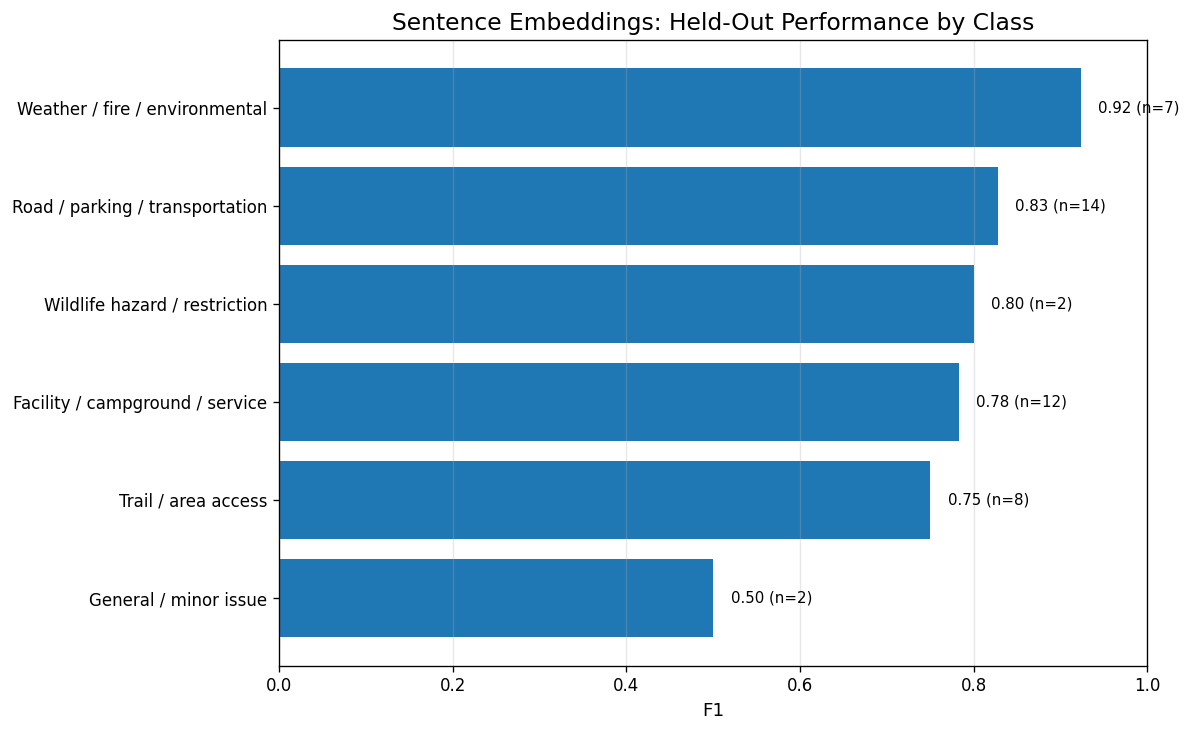

In [ ]:

selected_class_df = (
    embedding_per_class_df.loc[
        embedding_per_class_df[
            "evaluation_setting"
        ].eq("Held-out parks")
        & embedding_per_class_df[
            "partition"
        ].eq("test")
    ]
    .copy()
)

if "display_label" not in selected_class_df.columns:
    selected_class_df["display_label"] = (
        selected_class_df["primary_label"]
        .map(DISPLAY_LABELS)
    )

selected_class_df = (
    selected_class_df
    .sort_values("f1", ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 6.2))

ax.barh(
    selected_class_df["display_label"],
    selected_class_df["f1"],
)

ax.set_xlabel("F1")
ax.set_xlim(0, 1)
ax.set_title(
    "Sentence Embeddings: Held-Out Performance by Class"
)
ax.grid(axis="x", linewidth=0.8, alpha=0.3)

for index, row in enumerate(
    selected_class_df.itertuples()
):
    ax.text(
        row.f1 + 0.02,
        index,
        f"{row.f1:.2f} (n={int(row.support)})",
        va="center",
        fontsize=9,
    )

plt.tight_layout()
plt.show()



### Interpretation

This figure should accompany the confusion matrix. It shows both the strength of the selected model and the uncertainty caused by very small support for the rare classes.


## Figure 6. Grouped cross-validation robustness

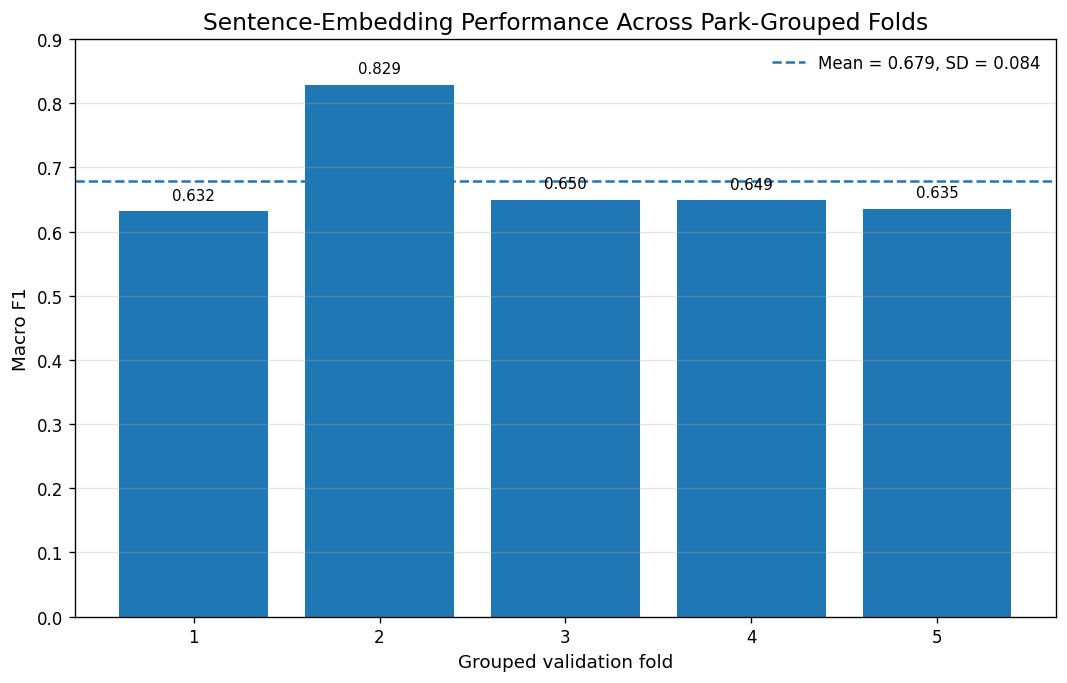

In [ ]:

cv_plot_df = grouped_cv_folds_df.copy()

fig, ax = plt.subplots(figsize=(9, 5.8))

ax.bar(
    cv_plot_df["fold"].astype(str),
    cv_plot_df["macro_f1"],
)

mean_macro_f1 = cv_plot_df["macro_f1"].mean()
std_macro_f1 = cv_plot_df["macro_f1"].std(ddof=1)

ax.axhline(
    mean_macro_f1,
    linewidth=1.5,
    linestyle="--",
    label=(
        f"Mean = {mean_macro_f1:.3f}, "
        f"SD = {std_macro_f1:.3f}"
    ),
)

ax.set_xlabel("Grouped validation fold")
ax.set_ylabel("Macro F1")
ax.set_ylim(0, 0.9)
ax.set_title(
    "Sentence-Embedding Performance Across Park-Grouped Folds"
)
ax.legend(frameon=False)
ax.grid(axis="y", linewidth=0.8, alpha=0.3)

for index, value in enumerate(cv_plot_df["macro_f1"]):
    ax.text(
        index,
        value + 0.018,
        f"{value:.3f}",
        ha="center",
        fontsize=9,
    )

plt.tight_layout()
plt.show()


## Figure 7. Fixed held-out result versus grouped-CV distribution

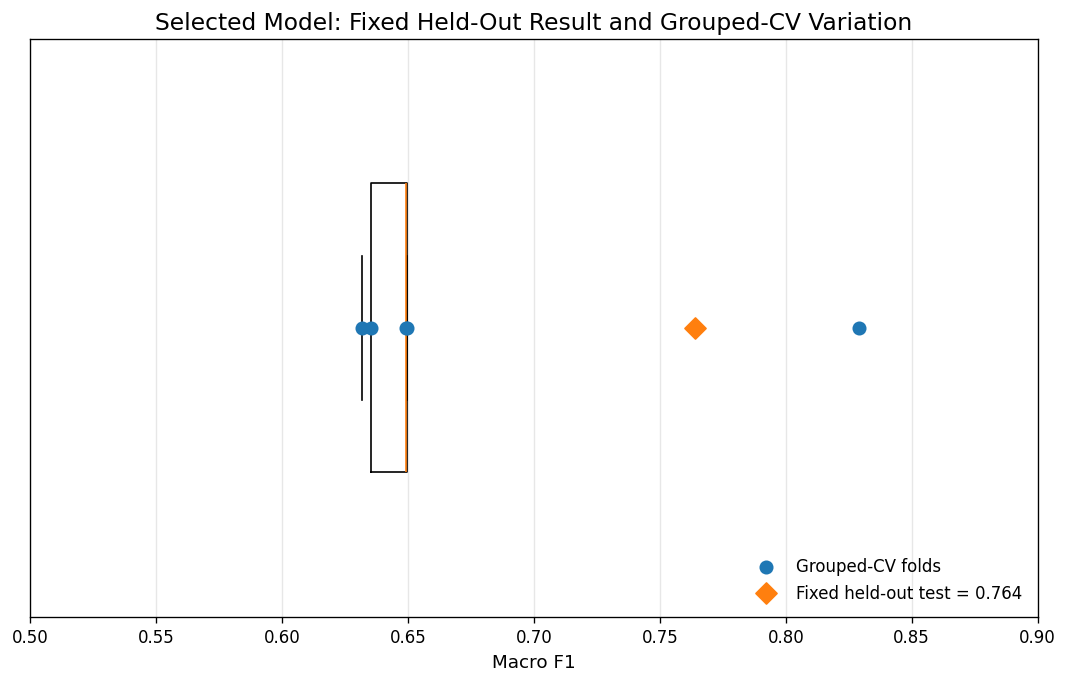

In [ ]:

heldout_macro_f1 = float(
    selected_test_df.loc[
        selected_test_df[
            "evaluation_setting"
        ].eq("Held-out parks"),
        "macro_f1",
    ].iloc[0]
)

cv_values = cv_plot_df["macro_f1"].to_numpy()

fig, ax = plt.subplots(figsize=(9, 5.8))

ax.boxplot(
    cv_values,
    vert=False,
    widths=0.5,
)

ax.scatter(
    cv_values,
    np.ones_like(cv_values),
    s=55,
    zorder=3,
    label="Grouped-CV folds",
)

ax.scatter(
    [heldout_macro_f1],
    [1],
    marker="D",
    s=80,
    zorder=4,
    label=f"Fixed held-out test = {heldout_macro_f1:.3f}",
)

ax.set_yticks([])
ax.set_xlabel("Macro F1")
ax.set_title(
    "Selected Model: Fixed Held-Out Result and Grouped-CV Variation"
)
ax.set_xlim(0.5, 0.9)
ax.legend(frameon=False, loc="lower right")
ax.grid(axis="x", linewidth=0.8, alpha=0.3)

plt.tight_layout()
plt.show()


# Structured error analysis

## 5. Prepare selected-model held-out errors

In [ ]:

selected_errors_df = (
    selected_heldout_predictions.loc[
        selected_heldout_predictions[
            "primary_label"
        ].ne(
            selected_heldout_predictions[
                "predicted_label"
            ]
        )
    ]
    .copy()
    .reset_index(drop=True)
)

selected_errors_df["true_display"] = (
    selected_errors_df["primary_label"]
    .map(DISPLAY_LABELS)
)

selected_errors_df["predicted_display"] = (
    selected_errors_df["predicted_label"]
    .map(DISPLAY_LABELS)
)

display(
    selected_errors_df[
        [
            "parkCode",
            "title",
            "true_display",
            "predicted_display",
        ]
    ]
)


,parkCode,title,true_display,predicted_display
0,adam,Bag Policy,Facility / campground / service,General / minor issue
1,vafo,Dogs Prohibited on Grand Parade Trails from Ap...,Trail / area access,Wildlife hazard / restriction
2,fowa,"Lighthouse Area Closed until June 30, 2026",Trail / area access,Facility / campground / service
3,till,Ongoing Construction at the Emmett Till Interp...,Facility / campground / service,Road / parking / transportation
4,colt,Park in Progress,Facility / campground / service,Road / parking / transportation
5,muwo,Parking Reservations Always Required,Road / parking / transportation,Facility / campground / service
6,olym,South Shore Quinault Road Washed Out Beyond Pa...,Road / parking / transportation,Trail / area access
7,biso,The Use of Drones is Prohibited at Big South F...,General / minor issue,Road / parking / transportation
8,chir,Upper Rhyolite Trail Closure,Weather / fire / environmental,Trail / area access


## 5. Confusion-pair summary

In [ ]:

confusion_pairs_df = (
    selected_errors_df
    .groupby(
        [
            "true_display",
            "predicted_display",
        ]
    )
    .size()
    .reset_index(name="count")
    .sort_values(
        "count",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(confusion_pairs_df)


,true_display,predicted_display,count
0,Facility / campground / service,Road / parking / transportation,2
1,Facility / campground / service,General / minor issue,1
2,General / minor issue,Road / parking / transportation,1
3,Road / parking / transportation,Facility / campground / service,1
4,Road / parking / transportation,Trail / area access,1
5,Trail / area access,Facility / campground / service,1
6,Trail / area access,Wildlife hazard / restriction,1
7,Weather / fire / environmental,Trail / area access,1


## Figure 8. Most common error directions

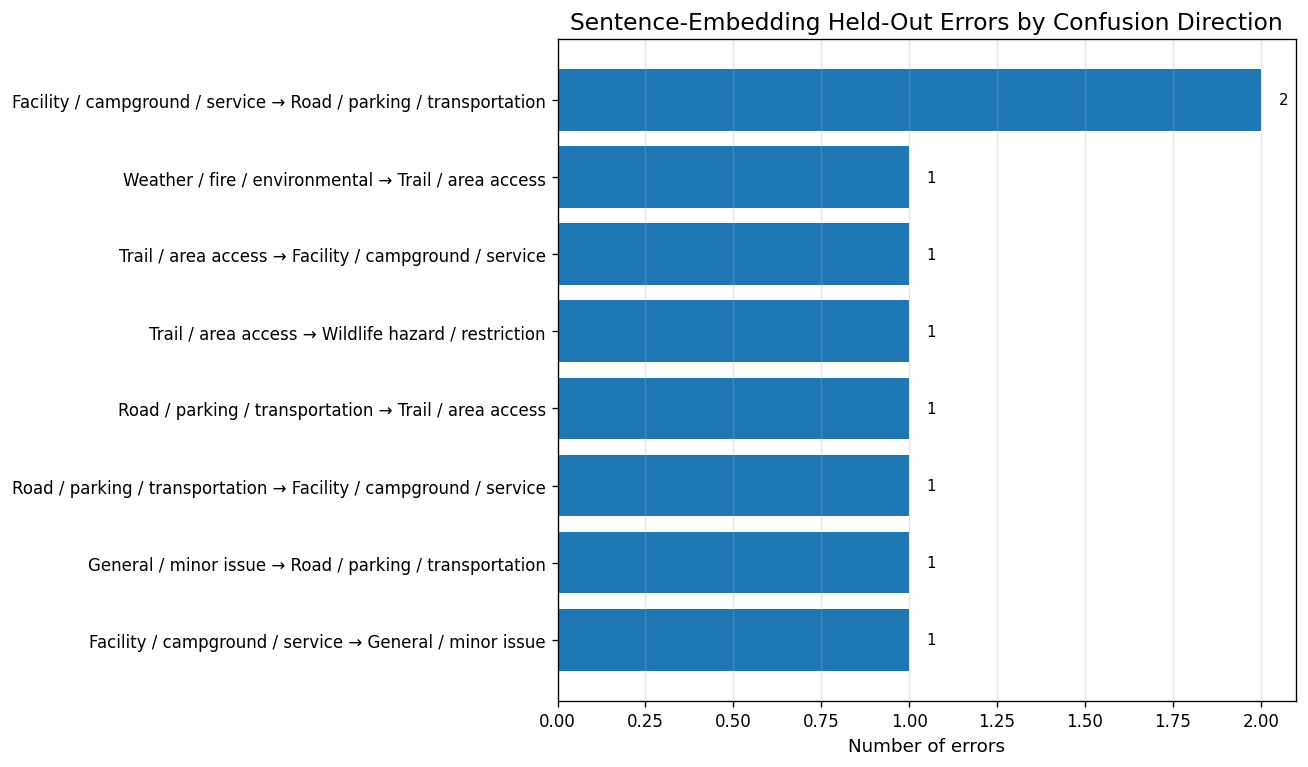

In [ ]:

if len(confusion_pairs_df) > 0:
    error_plot_df = (
        confusion_pairs_df
        .assign(
            direction=lambda frame: (
                frame["true_display"]
                + " → "
                + frame["predicted_display"]
            )
        )
        .sort_values("count", ascending=True)
    )

    fig, ax = plt.subplots(figsize=(11, 6.5))

    ax.barh(
        error_plot_df["direction"],
        error_plot_df["count"],
    )

    ax.set_xlabel("Number of errors")
    ax.set_title(
        "Sentence-Embedding Held-Out Errors by Confusion Direction"
    )
    ax.grid(axis="x", linewidth=0.8, alpha=0.3)

    for index, value in enumerate(error_plot_df["count"]):
        ax.text(
            value + 0.05,
            index,
            str(value),
            va="center",
            fontsize=9,
        )

    plt.tight_layout()
    plt.show()
else:
    print("No held-out errors were found.")


# Final report tables

## 8. Selected-model summary

In [ ]:

selected_summary_table = (
    selected_test_df[
        [
            "evaluation_setting",
            "n",
            "accuracy",
            "macro_f1",
            "weighted_f1",
        ]
    ]
    .sort_values("evaluation_setting")
    .reset_index(drop=True)
)

display(selected_summary_table.round(3))


,evaluation_setting,n,accuracy,macro_f1,weighted_f1
0,Held-out parks,45,0.800,0.764,0.801
1,Mixed parks,45,0.778,0.660,0.758


## 9. Grouped-CV summary

In [ ]:

display(grouped_cv_summary_df.round(3))


,metric,mean,standard_deviation
0,accuracy,0.775,0.042
1,macro_f1,0.679,0.084
2,weighted_f1,0.766,0.048


## 10. Final interpretation




1. Sentence embeddings produced the strongest held-out-park performance.
2. TF-IDF performed much better in the mixed-park setting than on unseen parks, suggesting sensitivity to park-specific wording.
3. The rule-based model generalized consistently but did not match the semantic performance of sentence embeddings.
4. Fine-tuned DistilBERT did not outperform frozen sentence embeddings, which is consistent with the limited and imbalanced labeled sample.
5. Grouped cross-validation showed meaningful variability across different held-out park groups, so the fixed held-out score should be interpreted alongside the cross-validation mean and standard deviation.
6. The rare and heterogeneous general/minor class remained the least stable category.
7. Many errors reflected overlap between cause and affected resource.


# Export results and figures

In [ ]:

preferred_output_dirs = [
    Path("/content/nps_final_analysis_outputs"),
    Path("/mnt/data/nps_final_analysis_outputs"),
    Path("nps_final_analysis_outputs"),
]

output_dir = None

for candidate in preferred_output_dirs:
    try:
        candidate.mkdir(parents=True, exist_ok=True)
        output_dir = candidate
        break
    except (PermissionError, OSError):
        continue

if output_dir is None:
    raise PermissionError(
        "Could not create an output directory."
    )

figures_dir = output_dir / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

print("Output directory:", output_dir.resolve())


Output directory: /content/nps_final_analysis_outputs



## 11. Save figures


In [ ]:

# Figure 1: model comparison
fig, ax = plt.subplots(figsize=(11, 6.5))
ax.bar(
    x - width / 2,
    heldout_values,
    width,
    label="Held-out parks",
)
ax.bar(
    x + width / 2,
    mixed_values,
    width,
    label="Mixed parks",
)
ax.set_ylabel("Macro F1")
ax.set_title("Model Performance by Evaluation Setting")
ax.set_xticks(x)
ax.set_xticklabels(plot_df.index)
ax.set_ylim(0, 0.9)
ax.legend(frameon=False)
ax.grid(axis="y", linewidth=0.8, alpha=0.35)
for index, value in enumerate(heldout_values):
    ax.text(
        index - width / 2,
        value + 0.018,
        f"{value:.2f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )
for index, value in enumerate(mixed_values):
    ax.text(
        index + width / 2,
        value + 0.018,
        f"{value:.2f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )
plt.tight_layout()
fig.savefig(
    figures_dir / "figure_1_final_model_comparison.png",
    bbox_inches="tight",
)
plt.close(fig)

# Figure 2: generalization gap
fig, ax = plt.subplots(figsize=(10, 5.8))
ax.bar(
    gap_df["model_short"],
    gap_df[gap_col],
)
ax.axhline(0, linewidth=1)
ax.set_ylabel("Mixed Macro F1 − Held-out Macro F1")
ax.set_title("Generalization Gap by Model")
ax.grid(axis="y", linewidth=0.8, alpha=0.35)
for index, value in enumerate(gap_df[gap_col]):
    vertical_alignment = "bottom" if value >= 0 else "top"
    offset = 0.008 if value >= 0 else -0.008
    ax.text(
        index,
        value + offset,
        f"{value:.3f}",
        ha="center",
        va=vertical_alignment,
        fontsize=9,
    )
plt.tight_layout()
fig.savefig(
    figures_dir / "figure_2_generalization_gap.png",
    bbox_inches="tight",
)
plt.close(fig)

# Figure 3: class distribution
fig, ax = plt.subplots(figsize=(10, 6.2))
ax.barh(
    class_plot_df["display_label"],
    class_plot_df["count"],
)
ax.set_xlabel("Number of alerts")
ax.set_title("Gold-Standard Alert Distribution (N = 300)")
ax.grid(axis="x", linewidth=0.8, alpha=0.3)
for index, value in enumerate(class_plot_df["count"]):
    ax.text(
        value + 0.8,
        index,
        str(value),
        va="center",
        fontsize=9,
    )
plt.tight_layout()
fig.savefig(
    figures_dir / "figure_3_class_distribution.png",
    bbox_inches="tight",
)
plt.close(fig)

# Figure 4: selected-model confusion matrix
fig, ax = plt.subplots(figsize=(9.5, 8))
image = ax.imshow(matrix)
ax.set_xticks(np.arange(len(display_names)))
ax.set_yticks(np.arange(len(display_names)))
ax.set_xticklabels(display_names, rotation=45, ha="right")
ax.set_yticklabels(display_names)
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title(
    "Sentence Embeddings: Held-Out-Park Test Confusion Matrix"
)
for row in range(matrix.shape[0]):
    for column in range(matrix.shape[1]):
        ax.text(
            column,
            row,
            int(matrix[row, column]),
            ha="center",
            va="center",
        )
fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
fig.savefig(
    figures_dir / "figure_4_embedding_confusion_matrix.png",
    bbox_inches="tight",
)
plt.close(fig)

# Figure 5: selected-model per-class F1
fig, ax = plt.subplots(figsize=(10, 6.2))
ax.barh(
    selected_class_df["display_label"],
    selected_class_df["f1"],
)
ax.set_xlabel("F1")
ax.set_xlim(0, 1)
ax.set_title(
    "Sentence Embeddings: Held-Out Performance by Class"
)
ax.grid(axis="x", linewidth=0.8, alpha=0.3)
for index, row in enumerate(
    selected_class_df.itertuples()
):
    ax.text(
        row.f1 + 0.02,
        index,
        f"{row.f1:.2f} (n={int(row.support)})",
        va="center",
        fontsize=9,
    )
plt.tight_layout()
fig.savefig(
    figures_dir / "figure_5_embedding_per_class_f1.png",
    bbox_inches="tight",
)
plt.close(fig)

# Figure 6: grouped CV folds
fig, ax = plt.subplots(figsize=(9, 5.8))
ax.bar(
    cv_plot_df["fold"].astype(str),
    cv_plot_df["macro_f1"],
)
ax.axhline(
    mean_macro_f1,
    linewidth=1.5,
    linestyle="--",
    label=(
        f"Mean = {mean_macro_f1:.3f}, "
        f"SD = {std_macro_f1:.3f}"
    ),
)
ax.set_xlabel("Grouped validation fold")
ax.set_ylabel("Macro F1")
ax.set_ylim(0, 0.9)
ax.set_title(
    "Sentence-Embedding Performance Across Park-Grouped Folds"
)
ax.legend(frameon=False)
ax.grid(axis="y", linewidth=0.8, alpha=0.3)
for index, value in enumerate(cv_plot_df["macro_f1"]):
    ax.text(
        index,
        value + 0.018,
        f"{value:.3f}",
        ha="center",
        fontsize=9,
    )
plt.tight_layout()
fig.savefig(
    figures_dir / "figure_6_grouped_cv_folds.png",
    bbox_inches="tight",
)
plt.close(fig)

# Figure 7: fixed held-out vs grouped CV
fig, ax = plt.subplots(figsize=(9, 5.8))
ax.boxplot(
    cv_values,
    vert=False,
    widths=0.5,
)
ax.scatter(
    cv_values,
    np.ones_like(cv_values),
    s=55,
    zorder=3,
    label="Grouped-CV folds",
)
ax.scatter(
    [heldout_macro_f1],
    [1],
    marker="D",
    s=80,
    zorder=4,
    label=f"Fixed held-out test = {heldout_macro_f1:.3f}",
)
ax.set_yticks([])
ax.set_xlabel("Macro F1")
ax.set_title(
    "Selected Model: Fixed Held-Out Result and Grouped-CV Variation"
)
ax.set_xlim(0.5, 0.9)
ax.legend(frameon=False, loc="lower right")
ax.grid(axis="x", linewidth=0.8, alpha=0.3)
plt.tight_layout()
fig.savefig(
    figures_dir / "figure_7_heldout_vs_grouped_cv.png",
    bbox_inches="tight",
)
plt.close(fig)

print("Saved figures to:", figures_dir.resolve())


Saved figures to: /content/nps_final_analysis_outputs/figures


## 12. Save tables and error-review files

In [ ]:

final_comparison_table.to_csv(
    output_dir / "final_model_comparison_table.csv",
    index=False,
)

selected_summary_table.to_csv(
    output_dir / "selected_model_summary.csv",
    index=False,
)

selected_class_df.to_csv(
    output_dir / "selected_model_per_class_metrics.csv",
    index=False,
)

confusion_pairs_df.to_csv(
    output_dir / "selected_model_confusion_pairs.csv",
    index=False,
)

error_review_df.to_csv(
    output_dir / "selected_model_error_review.csv",
    index=False,
)

grouped_cv_folds_df.to_csv(
    output_dir / "selected_model_grouped_cv_folds.csv",
    index=False,
)

grouped_cv_summary_df.to_csv(
    output_dir / "selected_model_grouped_cv_summary.csv",
    index=False,
)

with pd.ExcelWriter(
    output_dir / "final_analysis_summary.xlsx",
    engine="openpyxl",
) as writer:
    final_comparison_table.to_excel(
        writer,
        sheet_name="Model_Comparison",
        index=False,
    )
    selected_summary_table.to_excel(
        writer,
        sheet_name="Selected_Model",
        index=False,
    )
    selected_class_df.to_excel(
        writer,
        sheet_name="Per_Class",
        index=False,
    )
    confusion_pairs_df.to_excel(
        writer,
        sheet_name="Confusion_Pairs",
        index=False,
    )
    error_review_df.to_excel(
        writer,
        sheet_name="Error_Review",
        index=False,
    )
    grouped_cv_folds_df.to_excel(
        writer,
        sheet_name="Grouped_CV_Folds",
        index=False,
    )
    grouped_cv_summary_df.to_excel(
        writer,
        sheet_name="Grouped_CV_Summary",
        index=False,
    )

analysis_summary = {
    "selected_model": (
        "sentence-transformers/all-MiniLM-L6-v2 "
        "+ logistic regression"
    ),
    "selected_text_input": "title_plus_description",
    "primary_evaluation": "held-out parks",
    "primary_metric": "Macro F1",
    "heldout_macro_f1": heldout_macro_f1,
    "grouped_cv_macro_f1_mean": float(
        mean_macro_f1
    ),
    "grouped_cv_macro_f1_sd": float(
        std_macro_f1
    ),
}

with open(
    output_dir / "final_analysis_summary.json",
    "w",
) as file:
    json.dump(
        analysis_summary,
        file,
        indent=2,
    )

print("Saved analysis outputs to:", output_dir.resolve())

for path in sorted(output_dir.rglob("*")):
    if path.is_file():
        print("-", path.relative_to(output_dir))


Saved analysis outputs to: /content/nps_final_analysis_outputs
- figures/figure_1_final_model_comparison.png
- figures/figure_2_generalization_gap.png
- figures/figure_3_class_distribution.png
- figures/figure_4_embedding_confusion_matrix.png
- figures/figure_5_embedding_per_class_f1.png
- figures/figure_6_grouped_cv_folds.png
- figures/figure_7_heldout_vs_grouped_cv.png
- final_analysis_summary.json
- final_analysis_summary.xlsx
- final_model_comparison_table.csv
- selected_model_confusion_pairs.csv
- selected_model_error_review.csv
- selected_model_grouped_cv_folds.csv
- selected_model_grouped_cv_summary.csv
- selected_model_per_class_metrics.csv
- selected_model_summary.csv
